In [1]:
import sys
import numpy as np
import cv2
from matplotlib import pyplot as plt
sys.path.append('../robot')
from common import arena
from observation_models.distance import DistanceObservationModel

In [2]:
low_probability = 10 ** -10
# Ranges for world x and y coordinates, indexed by map coordinates
map_frame = arena.MapFrame(100)

In [3]:
def plot_map(map_data):
    plt.figure(figsize=(8, 8))
    plt.imshow(
        map_data,
        cmap='gray_r',
        origin='lower',
        extent=[map_frame.w_left, map_frame.w_right, map_frame.w_bottom, map_frame.w_top]
    )

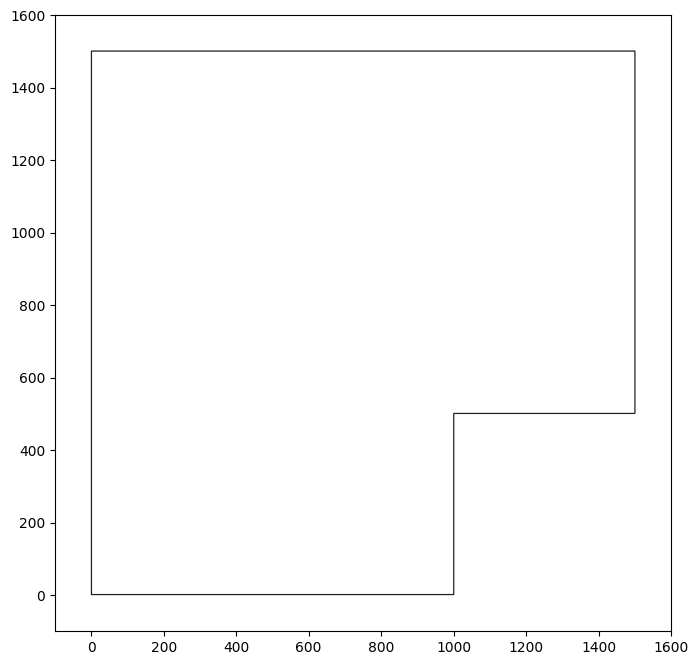

In [4]:
walls_map = np.zeros((map_frame.height, map_frame.width), dtype=np.float32)
cv2.polylines(walls_map, 
              map_frame.world_to_map(np.array([arena.walls])), 
              isClosed=True, color=1.0, thickness=2)

plot_map(walls_map)

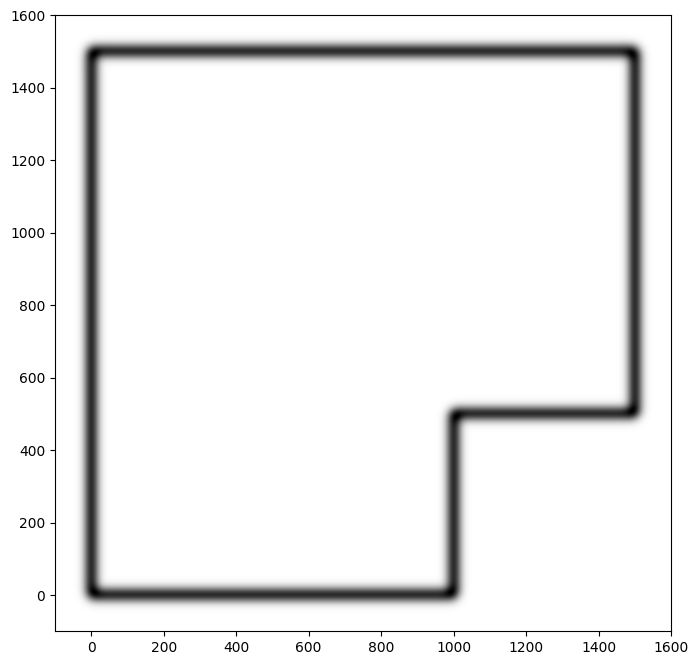

In [5]:
distance_map = cv2.GaussianBlur(walls_map, (0, 0), 15)
plot_map(distance_map)

Text(0.5, 1.0, 'Distance values along y = 200')

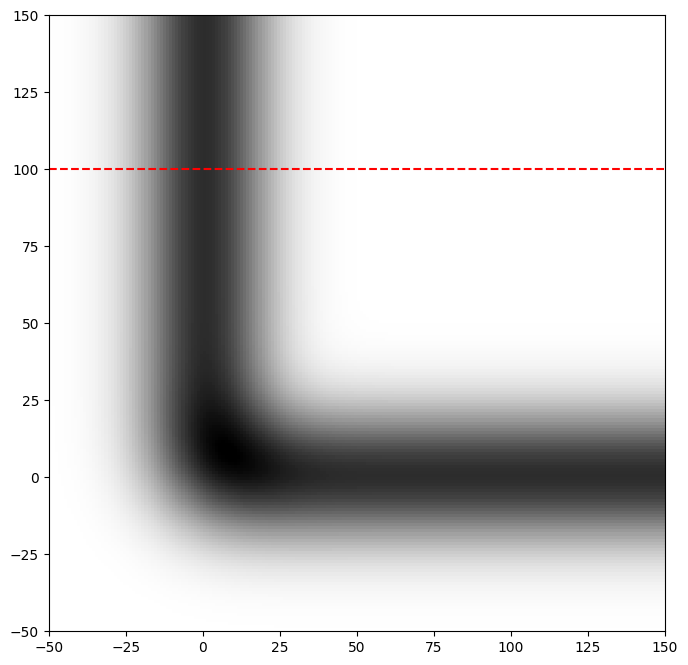

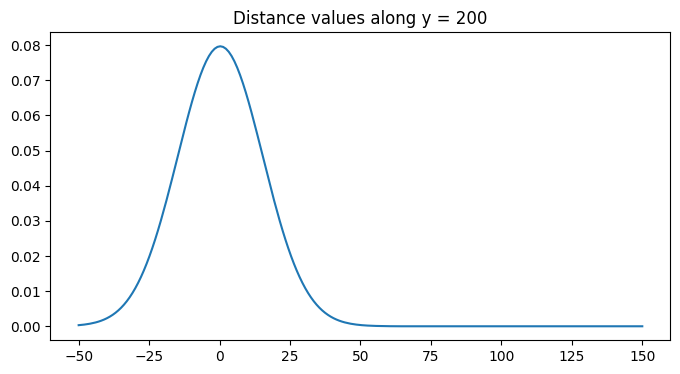

In [6]:
plot_map(distance_map)
axs = plt.gca()
axs.set_xlim(-50, 150)
axs.set_ylim(-50, 150)
# Draw a line at y = 150
plt.axhline(y=100, color='r', linestyle='--')
# # Draw a further plot of the row y = 100
map_y = 100 + map_frame.margin
row = distance_map[map_y, 50:250]
plt.figure(figsize=(8, 4))
plt.plot(np.linspace(-50, 150, 200), row)
plt.title(f'Distance values along y = {map_y}')

In [7]:
np.min(distance_map), np.max(distance_map)

(np.float32(0.0), np.float32(0.09661646))

(np.float32(1e-10), np.float32(1.0))

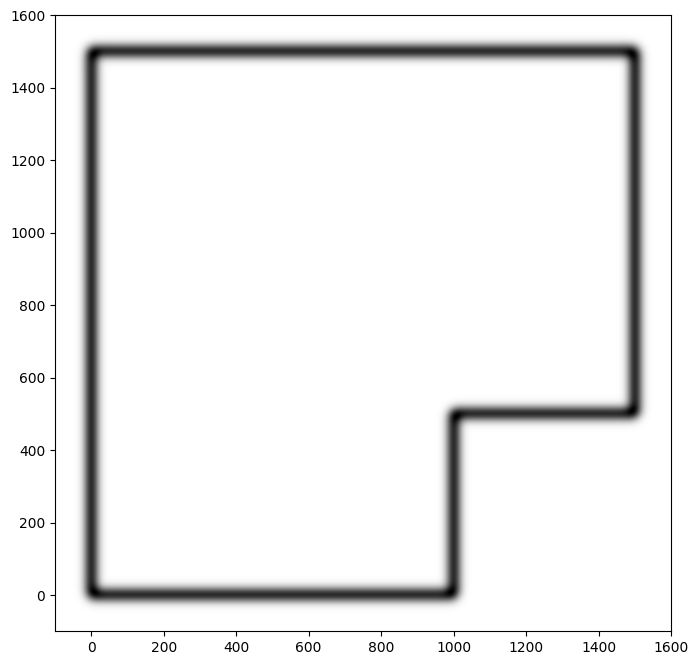

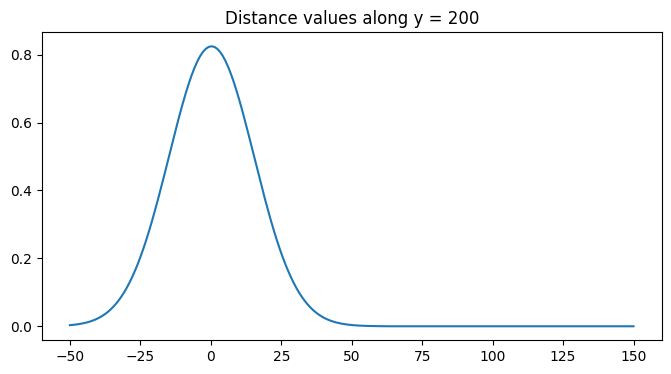

In [16]:
normalized_map = cv2.normalize(distance_map, None, alpha=low_probability, beta=1.0, norm_type=cv2.NORM_MINMAX)
plot_map(normalized_map)

row = normalized_map[map_y, 50:250]
plt.figure(figsize=(8, 4))
plt.plot(np.linspace(-50, 150, 200), row)
plt.title(f'Distance values along y = {map_y}')
np.min(normalized_map), np.max(normalized_map)

In [9]:
np.save('../robot/observation_models/distance_map.npy', normalized_map)

In [10]:
model = DistanceObservationModel("../robot/observation_models/distance_map.npy")
world_positions = np.array([[0, 0], [1705, 1500], [1500, 1200], [400, 400]])
model.get_probabilities(world_positions)

array([8.17359984e-01, 1.00000000e-10, 8.24649870e-01, 1.00000001e-10])

In [11]:
# An 8 by 8 grid of distance readings in mm, with 50mm in the first 4 rows, and 500mm in the last 4 rows
floor_rows = 4
remaining_rows = 4
array_width = 8
distance_readings = np.array([[50]*array_width]*floor_rows + [[500]*array_width]*remaining_rows)
# distance_readings = np.array([[50]*8] * 4 + [[562,556,545,539,434,375,397,334]] * 4)
distance_readings[5, 3] = 3000

In [12]:
model.handle_sensor_readings(distance_readings)
model.relative_sensor_positions

array([[ 511.93976626, -191.34171618],
       [ 530.45866097, -138.41775571],
       [ 542.93550926,  -83.75311165],
       [ 549.21340751,  -28.03522362],
       [ 549.21340751,   28.03522362],
       [ 542.93550926,   83.75311165],
       [ 530.45866097,  138.41775571],
       [ 511.93976626,  191.34171618]])

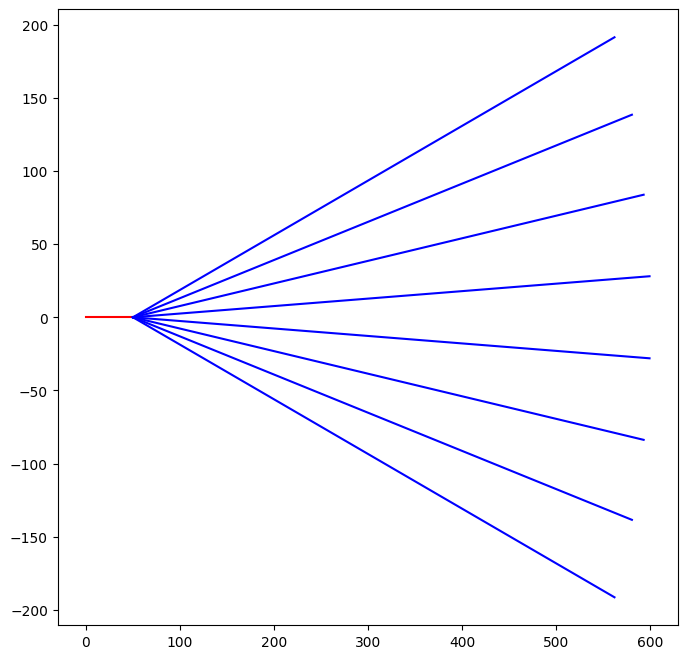

In [13]:
# Draw from the origin to the model forward offset
plt.figure(figsize=(8, 8))
plt.plot([0, model.sensor_forward_offset], [0, 0], 'r-')
# Draw the sensor positions relative to the forward offset
for sensor_pos in model.relative_sensor_positions:
    plt.plot([model.sensor_forward_offset, model.sensor_forward_offset + sensor_pos[0]], 
             [0, sensor_pos[1]], 'b-')

In [14]:
from common.poses import Poses
poses = Poses.generate(20, (300, 1000), (300, 1200), (0, 2 * np.pi))
poses

Poses([(431.31158,  328.2218 , 5.5377183 ),
       (947.7961 , 1018.9354 , 6.201531  ),
       (591.2911 ,  381.3996 , 2.2128372 ),
       (744.32007, 1198.2162 , 5.9574027 ),
       (563.9276 ,  834.5522 , 0.33431122),
       (644.1232 ,  966.2242 , 2.8362837 ),
       (656.60767,  348.06586, 1.2265346 ),
       (521.98395,  993.06335, 0.4263967 ),
       (822.8929 , 1157.3738 , 0.784359  ),
       (745.8518 ,  989.3051 , 4.352166  ),
       (787.0224 , 1187.7821 , 0.18950991),
       (683.5305 ,  377.26868, 5.579299  ),
       (550.8213 , 1123.1306 , 1.4754301 ),
       (881.35724, 1140.0547 , 1.3167294 ),
       (370.6468 ,  737.27686, 0.20204464),
       (739.30725,  954.07104, 4.4600086 ),
       (802.9982 ,  960.2299 , 4.180274  ),
       (910.83997,  889.89386, 0.8534519 ),
       (955.82855,  750.2033 , 4.9254036 ),
       (473.20776,  976.5336 , 3.3993676 )],
      dtype=[('x', '<f4'), ('y', '<f4'), ('theta', '<f4')])

In [15]:
# Combine sensor positions with poses to get the sensor positions in world coordinates
endpoints = model.sensor_endpoints(poses)
weights = model.calculate_weight(poses)
plot_map(walls_map)
for n, pose in enumerate(poses):
    x, y, theta = pose
    offset_x = x + model.sensor_forward_offset * np.cos(theta)
    offset_y = y + model.sensor_forward_offset * np.sin(theta)
    plt.plot([x, offset_x], [y, offset_y], 'g-', alpha=0.3)
    for sensor in range(8):
        plt.plot([offset_x, endpoints[n, sensor, 0]], 
                 [offset_y, endpoints[n, sensor, 1]], 'b-', alpha=0.3)
# Draw a scatter on the poses, such that it's a greyscale cmap based on the weight
plt.scatter(poses['x'], poses['y'], c=np.log(weights), cmap='Greys_r', s=100, alpha=0.7)

AttributeError: 'DistanceObservationModel' object has no attribute 'calculate_weight'